Saved: /Users/lilave/Desktop/Deterministic-Verification-of-CNN-Stability-via-the-Bivariate-Z-Transform/extracted_kernels/Notebooks/kernel_spectral_analysis.png


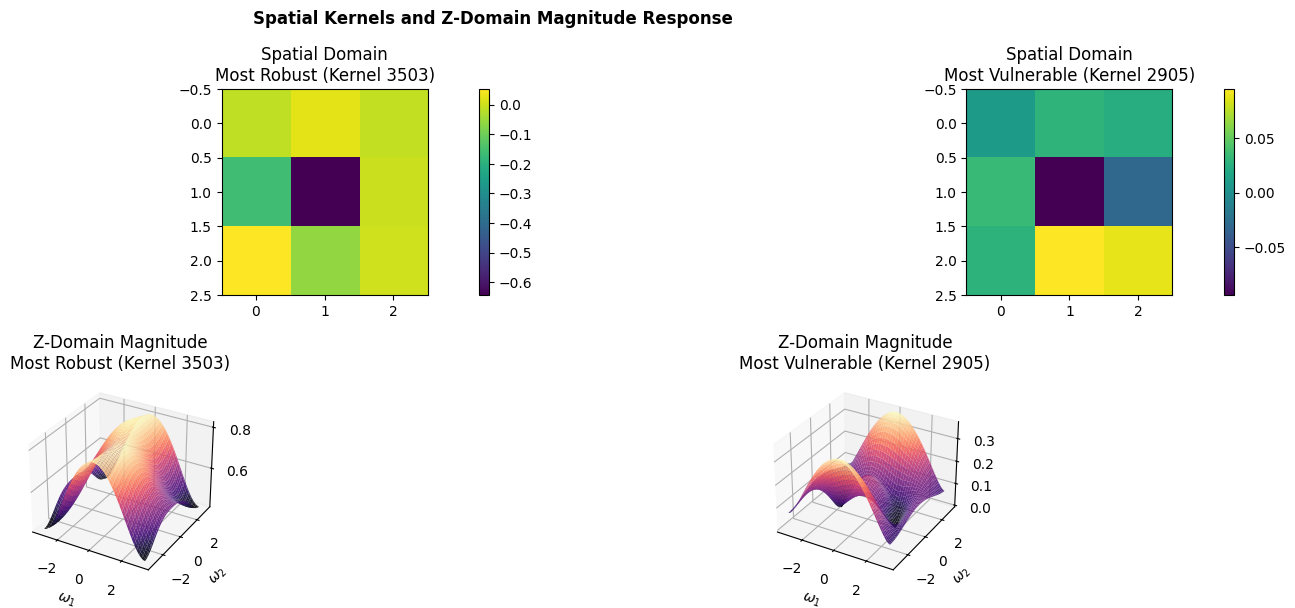

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import os
from sharedfunctions import (loadKernels, computeMagnitudeResponse,
                              IDXROBUST, IDXVULNERABLE, GRIDSIZE, CSVPATH)

kernels = loadKernels(CSVPATH)
omega = np.linspace(-np.pi, np.pi, GRIDSIZE)
W1, W2 = np.meshgrid(omega, omega)

fig = plt.figure(figsize=(18, 6))
fig.suptitle("Spatial Kernels and Z-Domain Magnitude Response",
             fontsize=12, fontweight='bold')

for plotCol, (idx, label) in enumerate([
        (IDXROBUST,     f"Most Robust (Kernel {IDXROBUST})"),
        (IDXVULNERABLE, f"Most Vulnerable (Kernel {IDXVULNERABLE})")]):

    h = kernels[idx]
    mag = computeMagnitudeResponse(h)

    # Spatial plot
    ax1 = fig.add_subplot(2, 2, plotCol + 1)
    im = ax1.imshow(h, cmap='viridis')
    ax1.set_title(f"Spatial Domain\n{label}")
    plt.colorbar(im, ax=ax1)

    # Magnitude response
    ax2 = fig.add_subplot(2, 2, plotCol + 3, projection='3d')
    ax2.plot_surface(W1, W2, mag, cmap='magma', edgecolor='none', alpha=0.9)
    ax2.set_title(f"Z-Domain Magnitude\n{label}")
    ax2.set_xlabel("$\\omega_1$")
    ax2.set_ylabel("$\\omega_2$")

filename = "kernel_spectral_analysis.png"
plt.tight_layout()
plt.savefig(filename, dpi=150, bbox_inches='tight')
print(f"Saved: {os.path.abspath(filename)}")
plt.show()